**<head>PROJET MLOPS</head>**

In [360]:
# !pip install  statsmodels 
# !pip install xgboost
# !pip install scikit-learn
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install statsmodels
# !pip install scipy
# !pip install scikit-learn
# !pip install pandas
# !pip install imbalanced-learn

In [361]:
# Importation des bibliothèques nécessaires
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
seeds = 42

In [362]:
# Chargement du jeu de données
data = pd.read_csv('Loan_data.csv')
# Description du jeu de données
display(data.shape)
display(data.size)
displaydescribe = data.describe()

# Affichage des premières lignes du jeu de données
display(data.head())
display(displaydescribe)

(10000, 8)

80000

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [363]:
# NOTE : Le scaling prématuré sur tout le dataset (y compris la target) a été supprimé.
# Le scaling est correctement réalisé dans le Pipeline (StandardScaler avant chaque modèle),
# ce qui évite tout data leakage lié au preprocessing.
# L'ancien code faisait : scaler.fit_transform(data) sur TOUTES les colonnes avant le split.

In [364]:
#Analyse des données manquantes
data.isnull().sum()
if data.isnull().sum().any():
    print("Il y a des données manquantes dans le dataset.")
else:
    print("Il n'y a pas de données manquantes dans le dataset.")

Il n'y a pas de données manquantes dans le dataset.


In [365]:
# Analyse des types de données
display(data.dtypes)
# Analyse des valeurs uniques
for column in data.columns:
    unique_values = data[column].nunique()
    print(f"Colonne '{column}' a {unique_values} valeurs uniques.")
else:
    print("Aucune colonne n'a qu'une seule valeur unique.")

customer_id                   int64
credit_lines_outstanding      int64
loan_amt_outstanding        float64
total_debt_outstanding      float64
income                      float64
years_employed                int64
fico_score                    int64
default                       int64
dtype: object

Colonne 'customer_id' a 10000 valeurs uniques.
Colonne 'credit_lines_outstanding' a 6 valeurs uniques.
Colonne 'loan_amt_outstanding' a 10000 valeurs uniques.
Colonne 'total_debt_outstanding' a 10000 valeurs uniques.
Colonne 'income' a 9995 valeurs uniques.
Colonne 'years_employed' a 11 valeurs uniques.
Colonne 'fico_score' a 374 valeurs uniques.
Colonne 'default' a 2 valeurs uniques.
Aucune colonne n'a qu'une seule valeur unique.


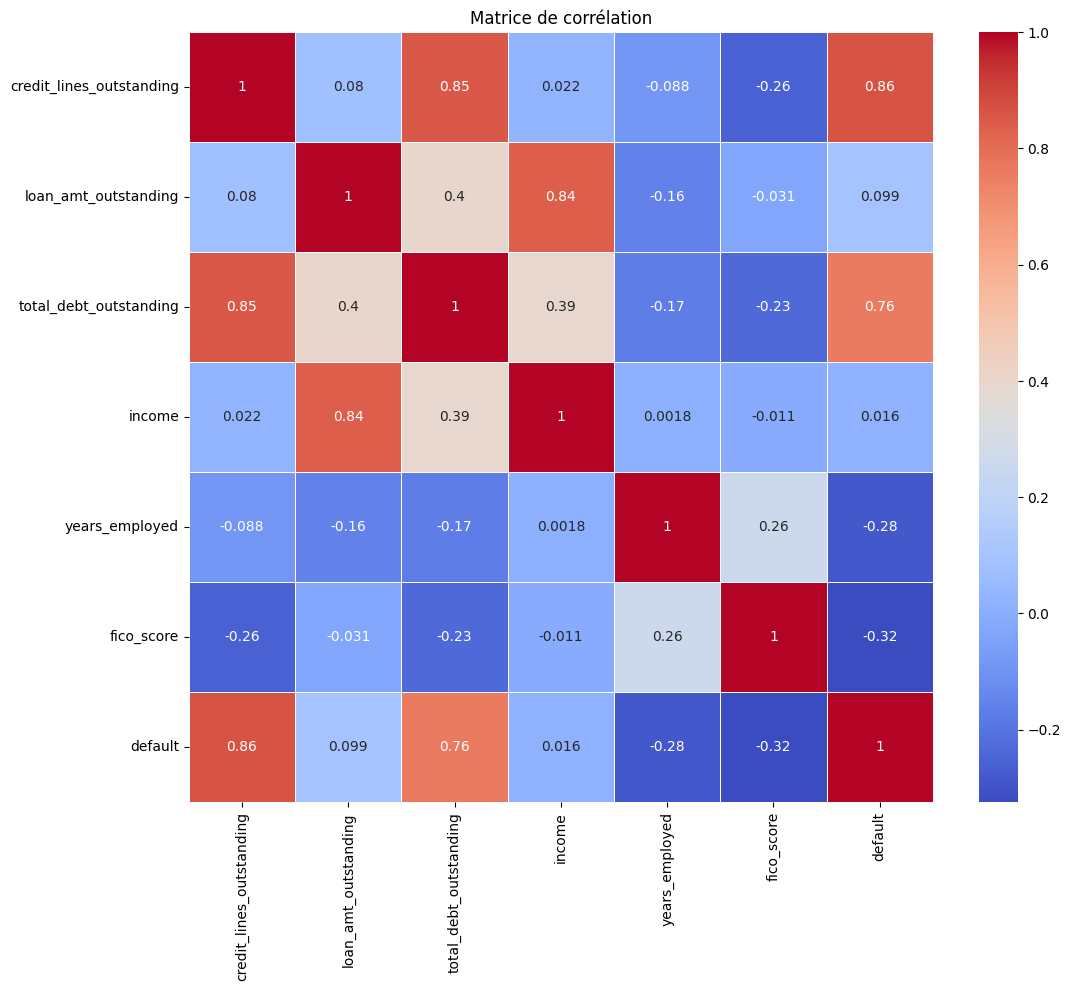

Correlations supérieures à 0,75 :


,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
credit_lines_outstanding,1.000000,NaN,0.852210,NaN,NaN,NaN,0.862815
loan_amt_outstanding,NaN,1.000000,NaN,0.835815,NaN,NaN,NaN
total_debt_outstanding,0.852210,NaN,1.000000,NaN,NaN,NaN,0.758868
income,NaN,0.835815,NaN,1.000000,NaN,NaN,NaN
years_employed,NaN,NaN,NaN,NaN,1.0,NaN,NaN
fico_score,NaN,NaN,NaN,NaN,NaN,1.0,NaN
default,0.862815,NaN,0.758868,NaN,NaN,NaN,1.000000


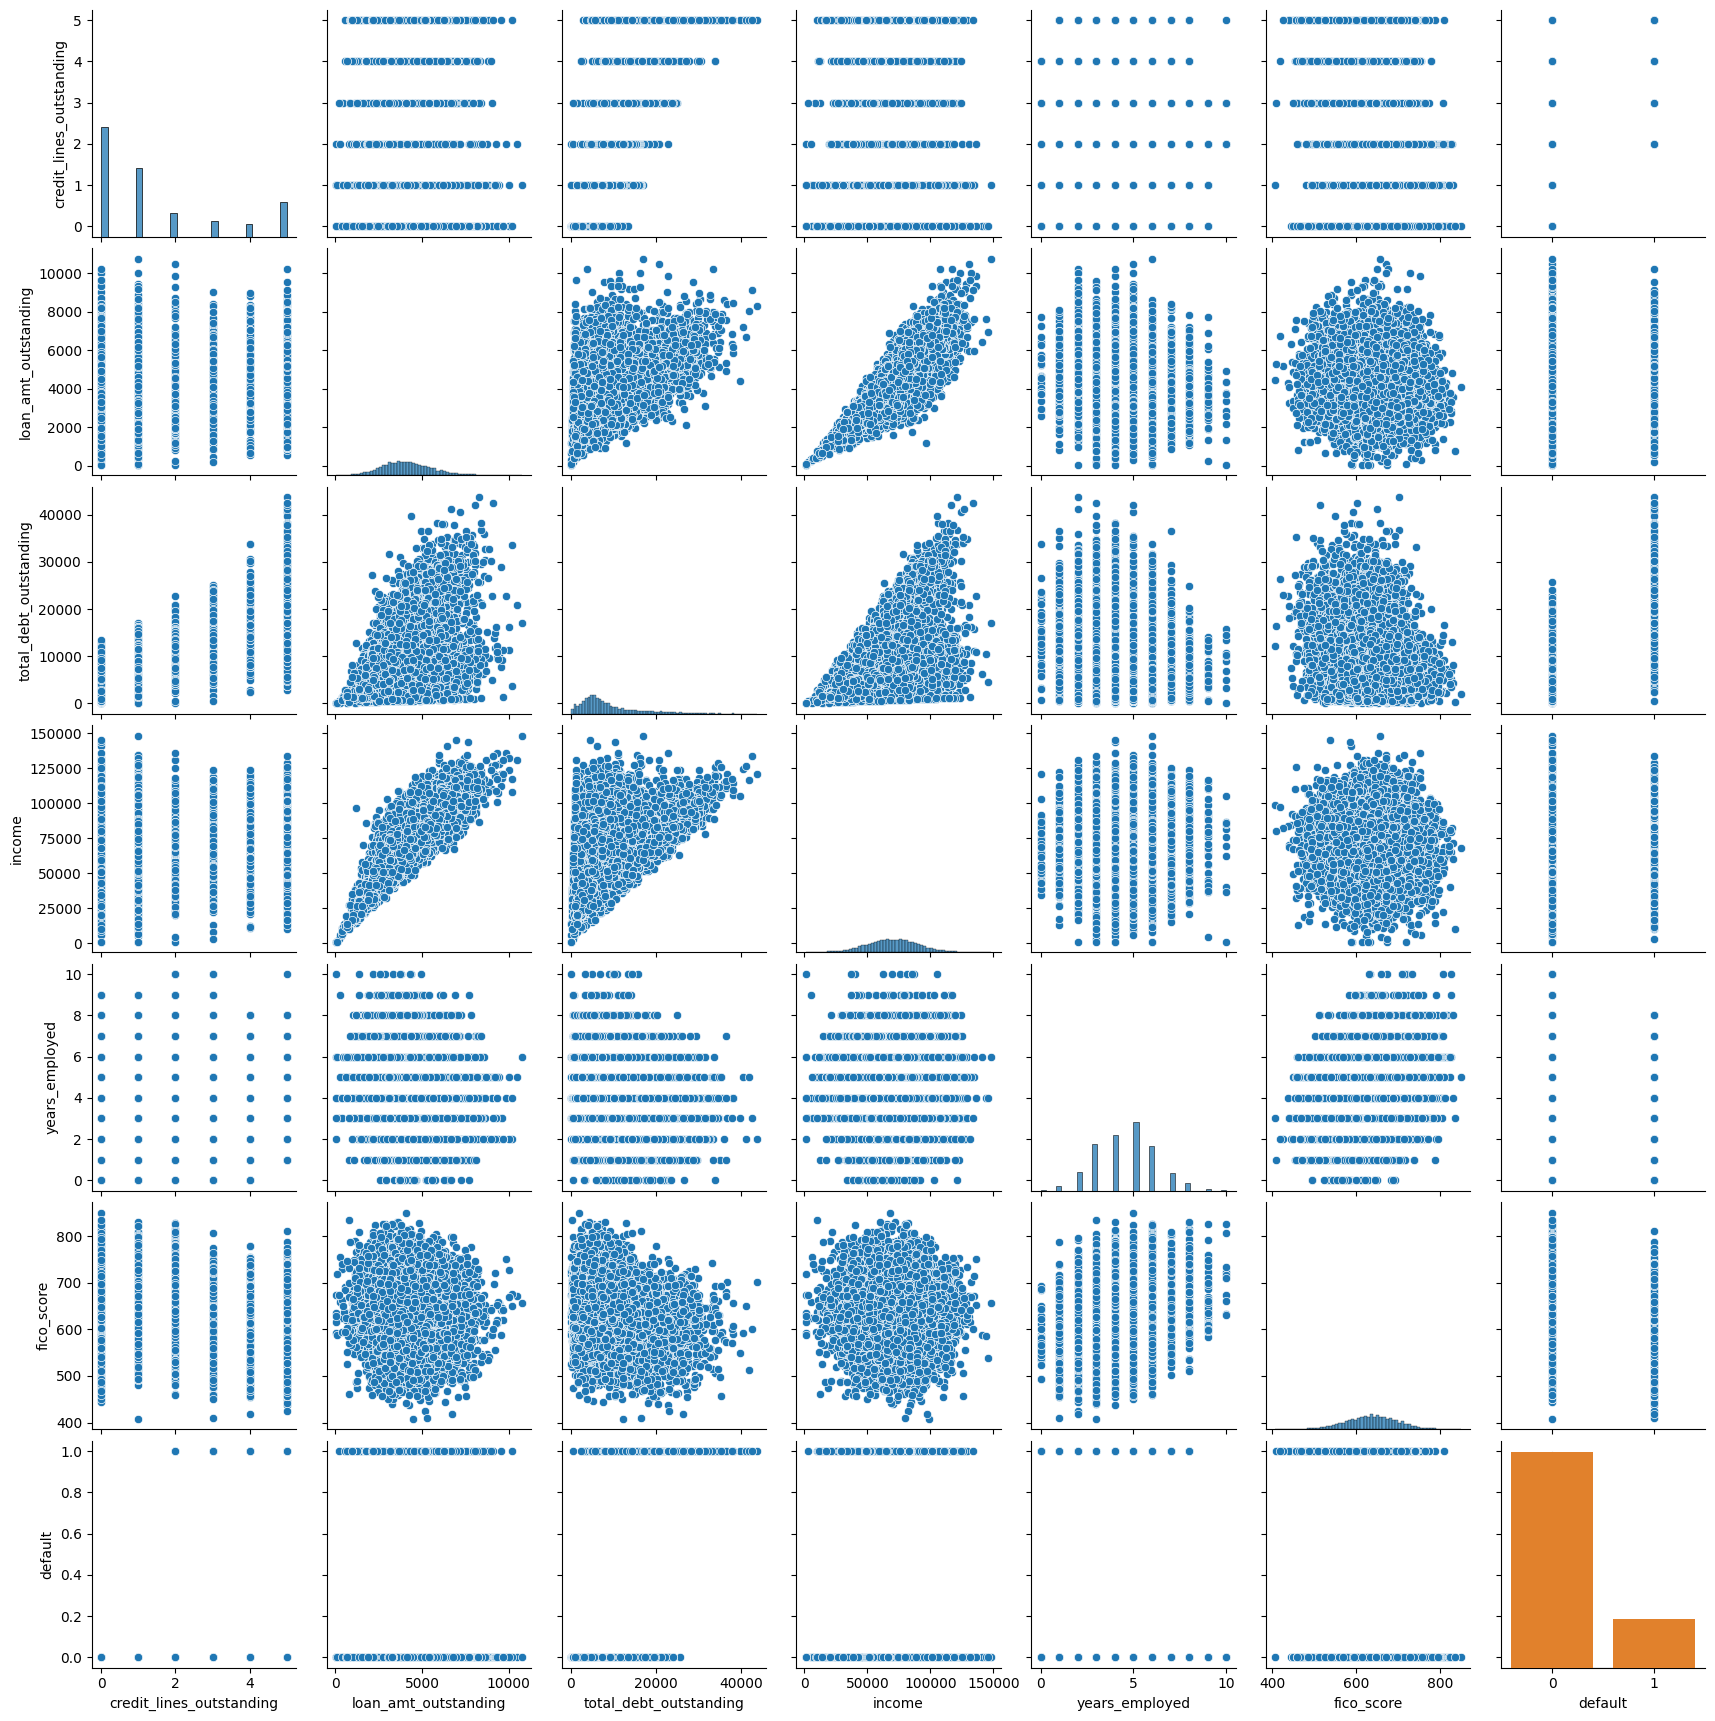

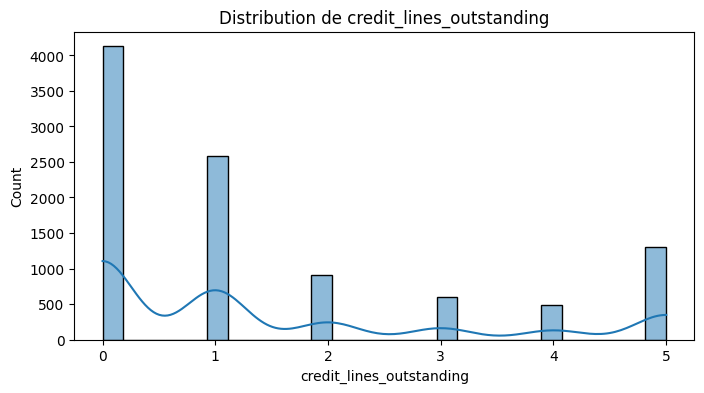

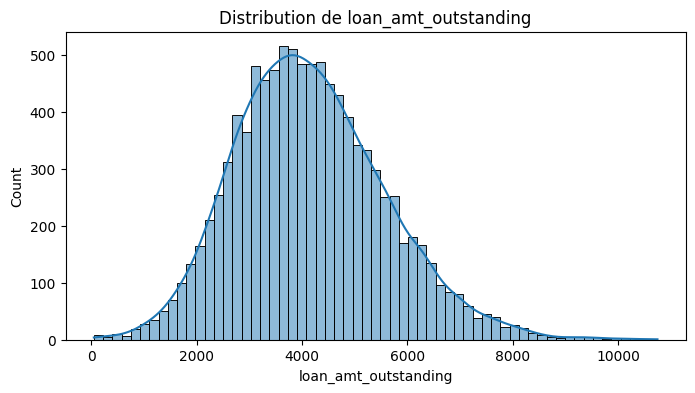

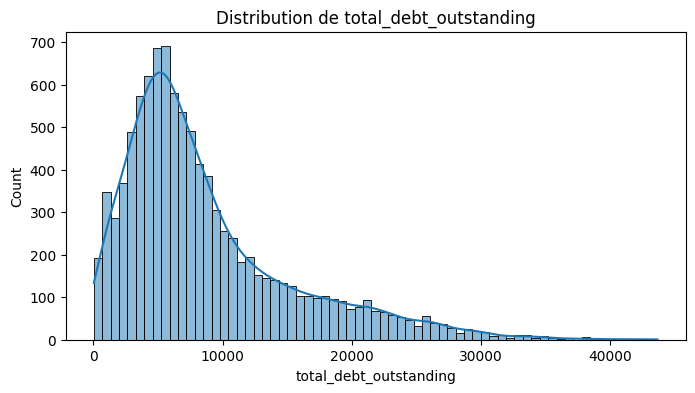

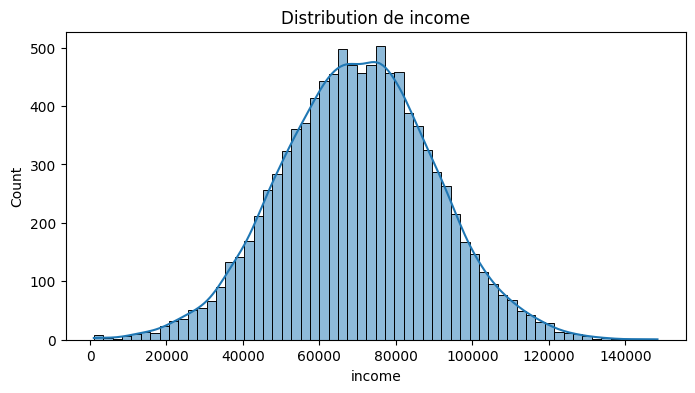

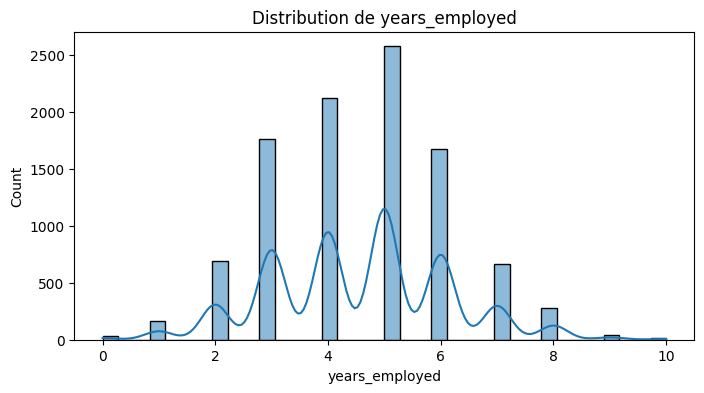

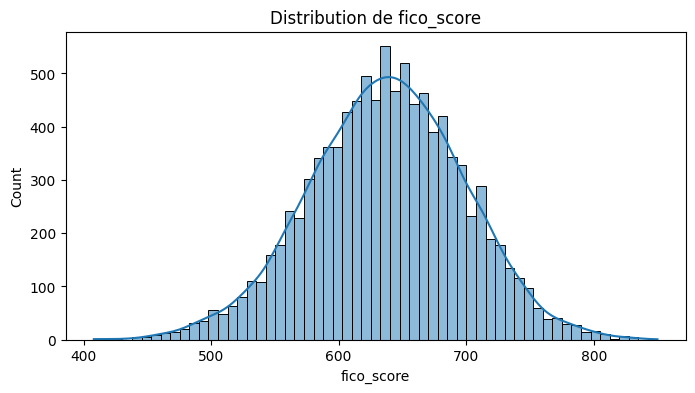

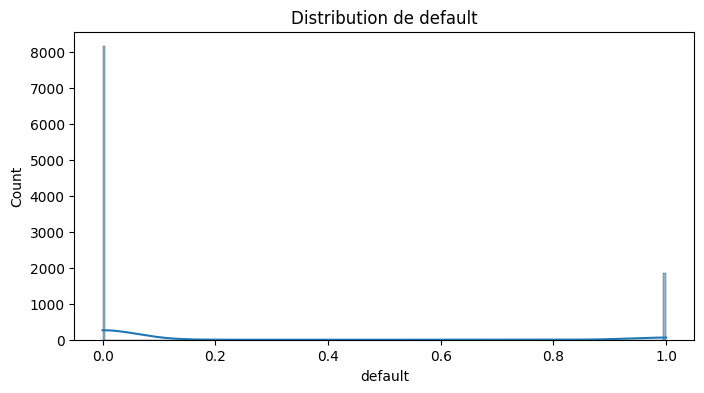

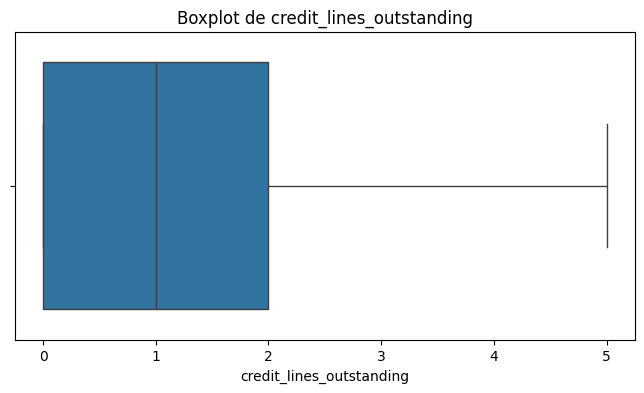

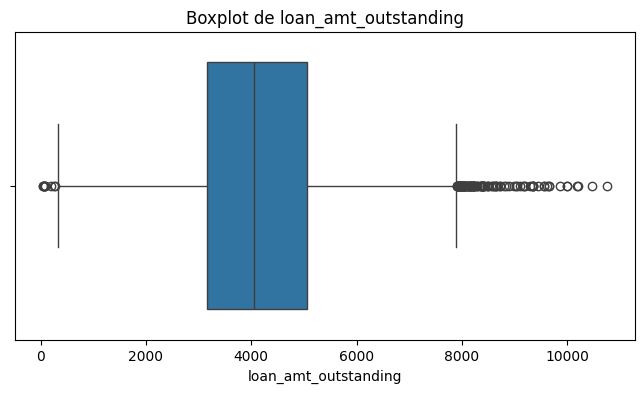

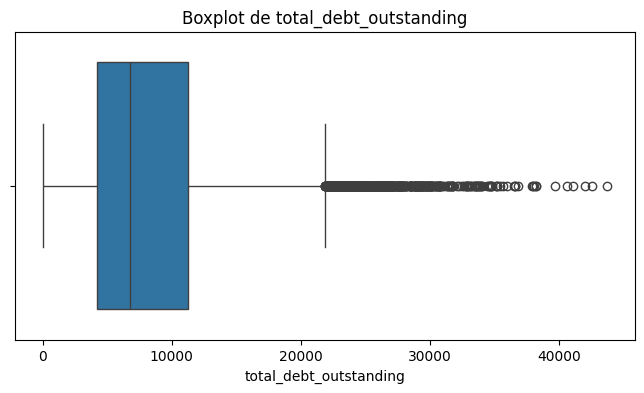

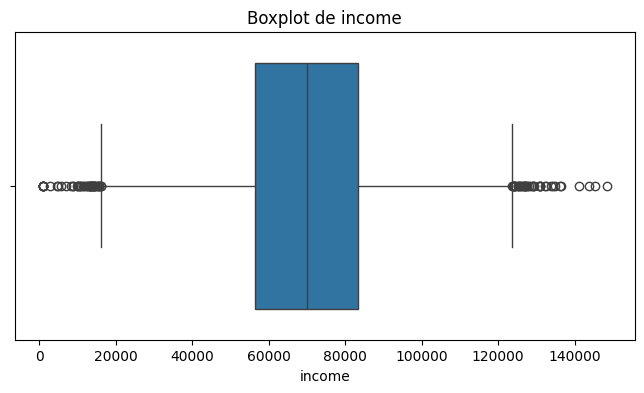

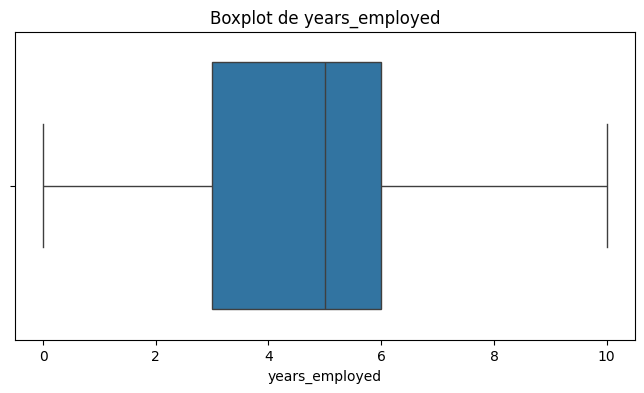

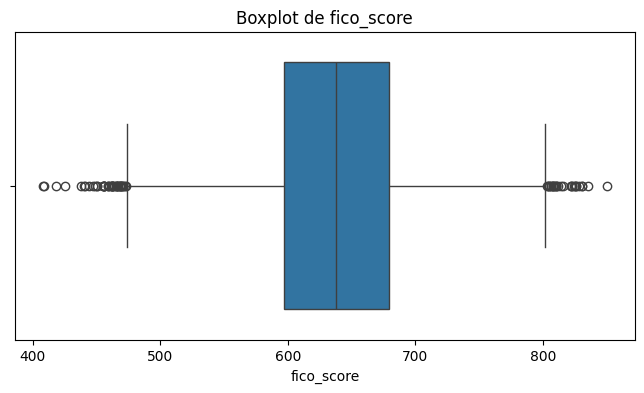

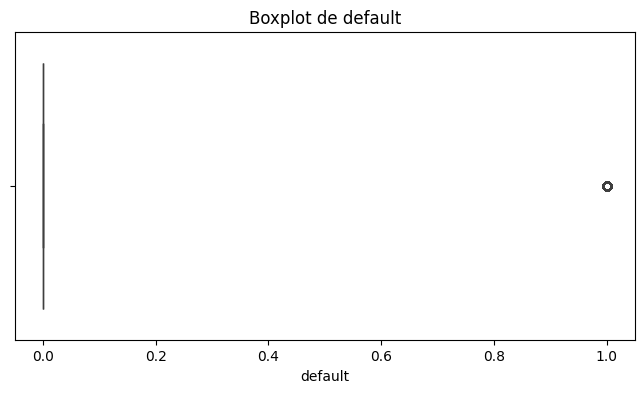

In [ ]:

data_net= data.drop(columns=['customer_id'])


# Matrice de corrélation

plt.figure(figsize=(12, 10))   
sns.heatmap(data_net.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matrice de corrélation') 
plt.show()
# Liste des corrélations > 0,8
correlation_matrix = data_net.corr()
high_correlation = correlation_matrix[correlation_matrix.abs()> 0.75]
print("Correlations supérieures à 0,75 :")
display(high_correlation)
# Matrice graphique de corrélation
sns.pairplot(data_net)
# Analyse de la distribution de la variable cible 'default'
sns.countplot(x='default', data=data_net)

# Visualisation de la distribution des variables numériques
#numeric_columns = data.select_dtypes(include=[np.number]).columns
for column in data_net:
    plt.figure(figsize=(8, 4))
    sns.histplot(data[column], kde=True)
    plt.title(f'Distribution de {column}')
    plt.show()

# Analyse des outliers avec des boxplots
for column in data_net:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data_net[column])
    plt.title(f'Boxplot de {column}')
    plt.show()



In [367]:
#check
print(type(data_net.corr()))
display(data_net.corr().size)
display(data_net.corr().shape)  


<class 'pandas.DataFrame'>


49

(7, 7)

# Investigation Data Leakage\nOn vérifie si certaines features encodent directement la variable cible `default`.\nUn taux de défaut très différent selon les modalités d'une feature = suspicion de leakage.

=== Crosstab credit_lines_outstanding vs default (taux par modalite) ===


default,0,1
credit_lines_outstanding,,
0,1.000000,0.000000
1,1.000000,0.000000
2,0.992239,0.007761
3,0.771285,0.228715
4,0.148760,0.851240
5,0.001542,0.998458



=== Effectifs credit_lines_outstanding vs default ===


default,0,1
credit_lines_outstanding,,
0,4128,0
1,2590,0
2,895,7
3,462,137
4,72,412
5,2,1295


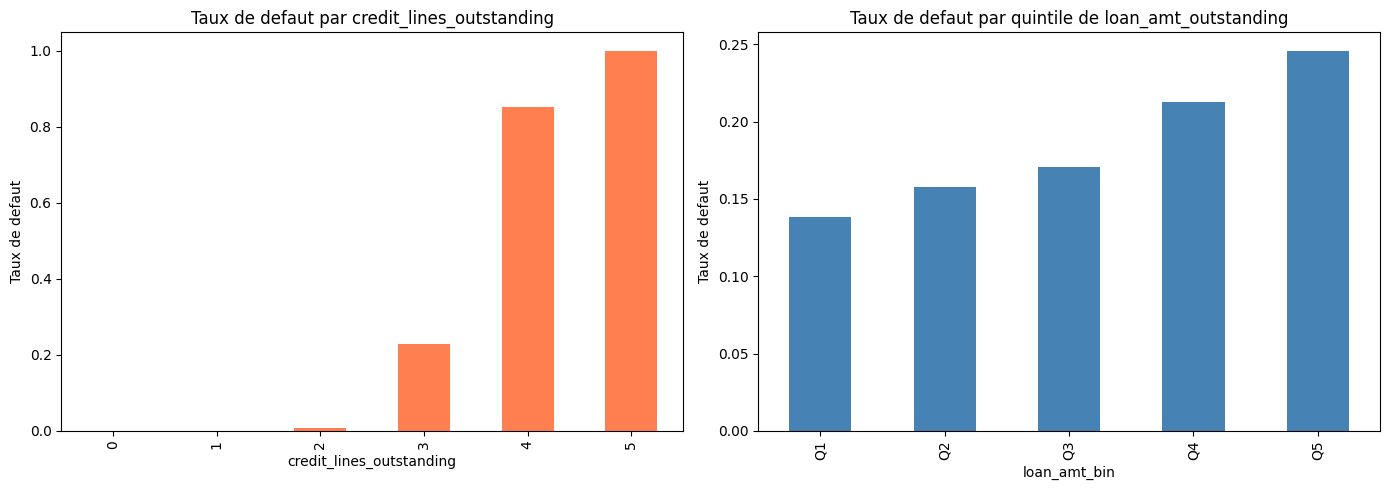


=== Conclusion ===
Si credit_lines_outstanding >= 3 implique default ~ 100%, c'est un data leaker.


In [368]:
# Investigation du leakage : relation entre credit_lines_outstanding et default
print("=== Crosstab credit_lines_outstanding vs default (taux par modalité) ===")
ct = pd.crosstab(data['credit_lines_outstanding'], data['default'], normalize='index')
display(ct)

print("\n=== Effectifs credit_lines_outstanding vs default ===")
display(pd.crosstab(data['credit_lines_outstanding'], data['default']))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux de défaut par credit_lines_outstanding
default_rate = data.groupby('credit_lines_outstanding')['default'].mean()
default_rate.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Taux de défaut par credit_lines_outstanding')
axes[0].set_ylabel('Taux de defaut')

# Taux de defaut par tranche de loan_amt_outstanding
data['loan_amt_bin'] = pd.qcut(data['loan_amt_outstanding'], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
default_rate_loan = data.groupby('loan_amt_bin')['default'].mean()
default_rate_loan.plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Taux de défaut par quintile de loan_amt_outstanding')
axes[1].set_ylabel('Taux de defaut')

plt.tight_layout()
plt.show()

# Nettoyage colonne temporaire
data.drop(columns=['loan_amt_bin'], inplace=True)

print("\n=== Conclusion ===")
print("Si credit_lines_outstanding >= 3 implique default ~ 100%, c'est un data leaker (fuite de données).")

# Définition FICO score:
* Le score FICO est un indicateur de solvabilité largement utilisé aux États-Unis pour évaluer le risque de crédit d’un emprunteur. Il permet aux établissements financiers d’estimer la probabilité qu’une personne rembourse correctement ses dettes.
Ce score est généralement compris entre 300 et 850. Plus il est élevé, plus le profil de crédit est considéré comme fiable. Il est notamment pris en compte lors de demandes de carte bancaire, de prêt automobile, de crédit immobilier ou de prêt personnel.
Le calcul du score FICO repose sur plusieurs éléments du dossier de crédit, parmi lesquels figurent l’historique des paiements, le niveau d’endettement, l’ancienneté du crédit, le nombre de nouvelles demandes de crédit ainsi que la diversité des types de crédit utilisés.
À titre indicatif, un score supérieur à 800 est considéré comme excellent, entre 740 et 799 comme très bon, entre 670 et 739 comme bon, entre 580 et 669 comme moyen, et inférieur à 580 comme faible.*

In [369]:
# Paradoxe: le fixo_score est ici peu corréler au défault 

In [370]:
# Suppression de la colonne 'default' 

data_vif= data_net.drop(columns=['default'])

print(data_vif.head())

   credit_lines_outstanding  loan_amt_outstanding  total_debt_outstanding  \
0                         0           5221.545193             3915.471226   
1                         5           1958.928726             8228.752520   
2                         0           3363.009259             2027.830850   
3                         0           4766.648001             2501.730397   
4                         1           1345.827718             1768.826187   

        income  years_employed  fico_score  
0  78039.38546               5         605  
1  26648.43525               2         572  
2  65866.71246               4         602  
3  74356.88347               5         612  
4  23448.32631               6         631  


In [371]:
# Analyse VIF   
# Calcul du VIF pour chaque variable
from statsmodels.stats.outliers_influence import variance_inflation_factor   
vif_values = [variance_inflation_factor(data_vif.values, i) for i in range(data_vif.shape[1])]
for i in range(len(vif_values)):
    print(f"VIF for {data_vif.columns[i]}: {vif_values[i]}")     

VIF for credit_lines_outstanding: 10.9488455880746
VIF for loan_amt_outstanding: 35.08803552231979
VIF for total_debt_outstanding: 21.937163377951418
VIF for income: 59.93081187684781
VIF for years_employed: 11.896744233503542
VIF for fico_score: 22.404741558573658


In [372]:
# Vérifier la relation entre credit_lines_outstanding et default
display(pd.crosstab(data['credit_lines_outstanding'], data['default'], normalize='index'))





default,0,1
credit_lines_outstanding,,
0,1.000000,0.000000
1,1.000000,0.000000
2,0.992239,0.007761
3,0.771285,0.228715
4,0.148760,0.851240
5,0.001542,0.998458


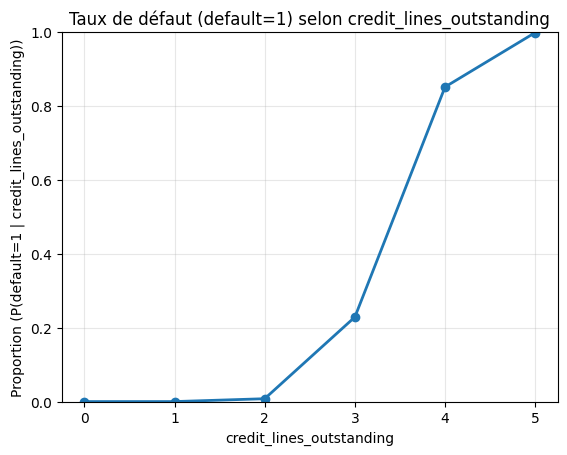

In [373]:

ct = pd.crosstab(
    data['credit_lines_outstanding'],
    data['default'],
    normalize='index'
)

# Courbe du taux de défaut (colonne 1)
ax = ct[1].plot(kind='line', marker='o', linewidth=2)

ax.set_title("Taux de défaut (default=1) selon credit_lines_outstanding")
ax.set_xlabel("credit_lines_outstanding")
ax.set_ylabel("Proportion (P(default=1 | credit_lines_outstanding))")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

plt.show()




In [374]:
# Préparation des données pour la modélisation
# CORRECTION : On retire credit_lines_outstanding (data leaker confirmé par le crosstab)
# et total_debt_outstanding (forte multicolinéarité)
X = data_net.drop(columns=['default', 'total_debt_outstanding', 'credit_lines_outstanding'])
y = data_net['default']

print("Features retenues :", list(X.columns))
display(X.shape)
display(y.shape)
display(y.value_counts(normalize=True))
print(X.head())

Features retenues : ['loan_amt_outstanding', 'income', 'years_employed', 'fico_score']


(10000, 4)

(10000,)

default
0    0.8149
1    0.1851
Name: proportion, dtype: float64

   loan_amt_outstanding       income  years_employed  fico_score
0           5221.545193  78039.38546               5         605
1           1958.928726  26648.43525               2         572
2           3363.009259  65866.71246               4         602
3           4766.648001  74356.88347               5         612
4           1345.827718  23448.32631               6         631


In [375]:
# Génaréation des données d'entraînement et de test / val sera traité par CV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seeds)

display(X_train.shape, y_train.shape,  X_test.shape, y_test.shape)

display(X_train.head())
display(y_train.head()) 

(8000, 4)

(8000,)

(2000, 4)

(2000,)

,loan_amt_outstanding,income,years_employed,fico_score
9005,5183.888841,74312.03972,3,550
8868,2831.062536,71076.73072,5,660
5117,5801.851720,71647.53368,3,636
3187,2313.910680,52610.08266,6,745
4257,6064.400513,114497.05240,8,677


9005    1
8868    0
5117    1
3187    0
4257    0
Name: default, dtype: int64


  Logistic Regression
Best params: {'model__C': 0.01}
Best CV Recall: 0.7184

--- Comparaison Train vs Test (detection overfitting) ---
  Train Accuracy : 0.7117
  Test  Accuracy : 0.7100
  Train Recall   : 0.7184
  Test  Recall   : 0.7027
  Train F1       : 0.4799
  Test  F1       : 0.4727
  >> OK : ecarts train-test raisonnables

--- Classification Report (Test) ---
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1630
           1       0.36      0.70      0.47       370

    accuracy                           0.71      2000
   macro avg       0.63      0.71      0.64      2000
weighted avg       0.81      0.71      0.74      2000



c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


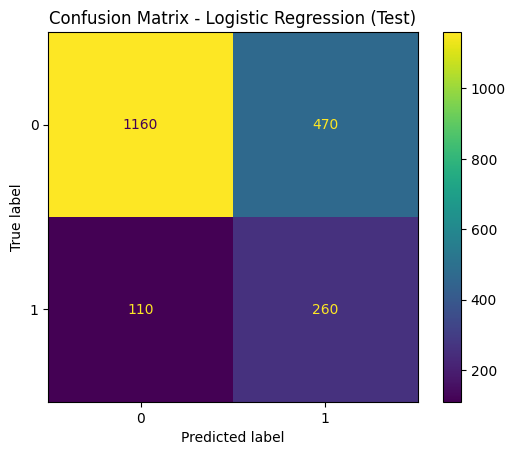


  Random Forest
Best params: {'model__max_depth': 3, 'model__n_estimators': 50}
Best CV Recall: 0.6968

--- Comparaison Train vs Test (detection overfitting) ---
  Train Accuracy : 0.7169
  Test  Accuracy : 0.7080
  Train Recall   : 0.7063
  Test  Recall   : 0.6568
  Train F1       : 0.4801
  Test  F1       : 0.4542
  >> OK : ecarts train-test raisonnables

--- Classification Report (Test) ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1630
           1       0.35      0.66      0.45       370

    accuracy                           0.71      2000
   macro avg       0.62      0.69      0.63      2000
weighted avg       0.80      0.71      0.74      2000



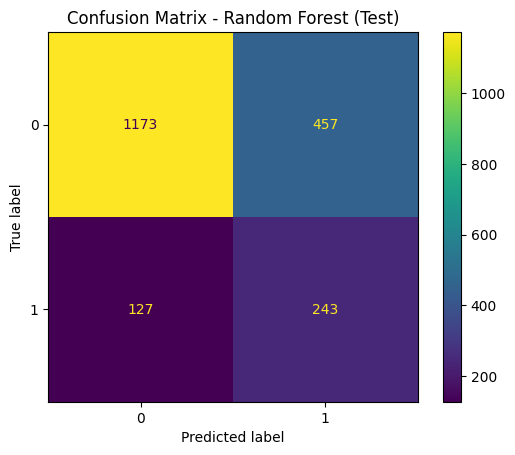


  XGBoost
Best params: {'model__max_depth': 3, 'model__n_estimators': 50, 'model__scale_pos_weight': 4}
Best CV Recall: 0.6448

--- Comparaison Train vs Test (detection overfitting) ---
  Train Accuracy : 0.7565
  Test  Accuracy : 0.7315
  Train Recall   : 0.7191
  Test  Recall   : 0.6054
  Train F1       : 0.5223
  Test  F1       : 0.4548
  >> ALERTE : ecart train-test important (acc gap=0.0250, recall gap=0.1137)

--- Classification Report (Test) ---
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1630
           1       0.36      0.61      0.45       370

    accuracy                           0.73      2000
   macro avg       0.63      0.68      0.64      2000
weighted avg       0.80      0.73      0.75      2000



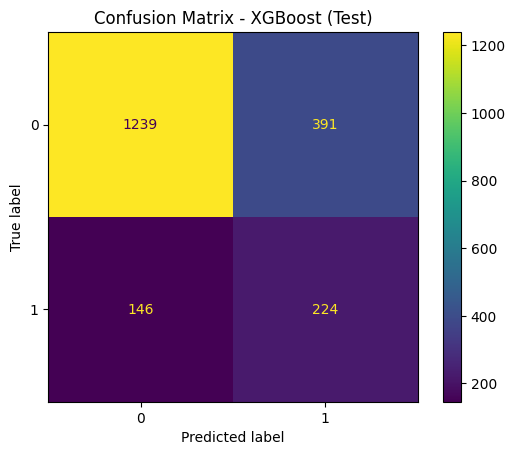


  MLP Classifier
Best params: {'model__hidden_layer_sizes': (80, 40, 24)}
Best CV Recall: 0.2614

--- Comparaison Train vs Test (detection overfitting) ---
  Train Accuracy : 0.8612
  Test  Accuracy : 0.8125
  Train Recall   : 0.4024
  Test  Recall   : 0.2514
  Train F1       : 0.5178
  Test  F1       : 0.3316
  >> ALERTE : ecart train-test important (acc gap=0.0487, recall gap=0.1511)

--- Classification Report (Test) ---
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      1630
           1       0.49      0.25      0.33       370

    accuracy                           0.81      2000
   macro avg       0.67      0.60      0.61      2000
weighted avg       0.78      0.81      0.79      2000



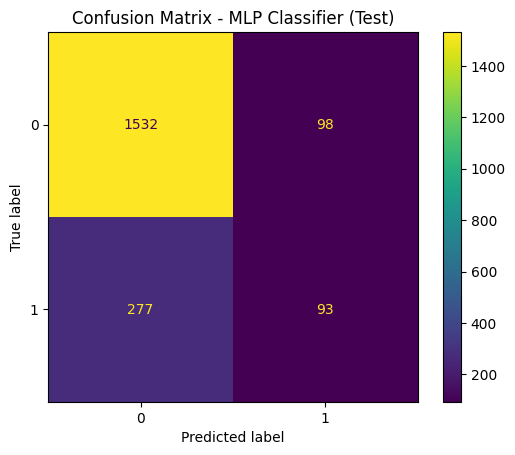


TOP 15 configs (tous modeles) :
         model_name  rank_test_score  mean_test_score  std_test_score                                                                            params
Logistic Regression                1         0.718434        0.013078                                                                {'model__C': 0.01}
      Random Forest                1         0.696826        0.021619                                {'model__max_depth': 3, 'model__n_estimators': 50}
            XGBoost                1         0.644829        0.008055  {'model__max_depth': 3, 'model__n_estimators': 50, 'model__scale_pos_weight': 4}
     MLP Classifier                1         0.261368        0.051902                                       {'model__hidden_layer_sizes': (80, 40, 24)}
Logistic Regression                2         0.714389        0.019422                                                                   {'model__C': 1}
      Random Forest                2         0.693443  

In [376]:
# Création du pipeline de modélisation

models = {
    "Logistic Regression": LogisticRegression(
        solver="saga",
        penalty="l1",
        max_iter=5000,
        random_state=seeds, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        random_state=seeds,
        class_weight="balanced"
    ),
    "XGBoost": XGBClassifier(
        random_state=seeds,
        eval_metric="logloss",
    ),
    "MLP Classifier": MLPClassifier(
        random_state=seeds,
        max_iter=500,
    )
}

gridsearch_params = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 5]
    },
    "Random Forest": {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [3, 5, 7]
    },
    "XGBoost": {
        "model__n_estimators": [50, 100, 200],
        "model__max_depth": [3, 5, 7],
        "model__scale_pos_weight": [4]  # ratio classes 0/1 ~ 0.815/0.185 ~ 4.4
    },
    "MLP Classifier": {
        "model__hidden_layer_sizes": [(32, 20), (80, 40, 24)]
    }
}

# ====================================
#  Boucle GridSearchCV + évaluation
# ====================================
all_results = []
best_models = {}

stratifiedkfold = sklearn.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=seeds)

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=gridsearch_params[name],
        cv=stratifiedkfold,
        scoring="recall",
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    best_models[name] = best_model

    # Predictions train et test
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Best params: {grid.best_params_}")
    print(f"Best CV Recall: {grid.best_score_:.4f}")

    # CORRECTION : Comparaison train vs test pour detecter overfitting
    print(f"\n--- Comparaison Train vs Test (détection de l'overfitting) ---")
    print(f"  Train Accuracy : {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"  Test  Accuracy : {accuracy_score(y_test, y_pred_test):.4f}")
    print(f"  Train Recall   : {recall_score(y_train, y_pred_train):.4f}")
    print(f"  Test  Recall   : {recall_score(y_test, y_pred_test):.4f}")
    print(f"  Train F1       : {f1_score(y_train, y_pred_train):.4f}")
    print(f"  Test  F1       : {f1_score(y_test, y_pred_test):.4f}")

    gap_acc = accuracy_score(y_train, y_pred_train) - accuracy_score(y_test, y_pred_test)
    gap_recall = recall_score(y_train, y_pred_train) - recall_score(y_test, y_pred_test)
    if gap_acc > 0.05 or gap_recall > 0.05:
        print(f"  >> ALERTE : écart train-test important (acc gap={gap_acc:.4f}, recall gap={gap_recall:.4f})")
    else:
        print(f"  >> OK : écarts train-test raisonnables")

    print(f"\n--- Classification Report (Test) ---")
    print(classification_report(y_test, y_pred_test))

    # Matrice de confusion test
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)
    plt.title(f"Confusion Matrix - {name} (Test)")
    plt.show()

    # Stockage cv_results
    cv_df = pd.DataFrame(grid.cv_results_)
    cv_df["model_name"] = name
    all_results.append(cv_df)

# ====================================
#  Tableau global : meilleures configurations
# ====================================
results_df = pd.concat(all_results, ignore_index=True)
top = (
    results_df[["model_name", "rank_test_score", "mean_test_score", "std_test_score", "params"]]
    .sort_values(["rank_test_score", "mean_test_score"], ascending=[True, False])
    .head(15)
)
print("\nTOP 15 configs (tous modèles) :")
print(top.to_string(index=False))

# Feature Importance & Learning Curves\nAnalyse de l'importance des features pour détecter si une seule variable domine (signe de leakage résiduel).\nLes learning curves permettent de visualiser l'overfitting : si le score train reste très haut tandis que le score de validation stagne bas, le modèle overfitte.

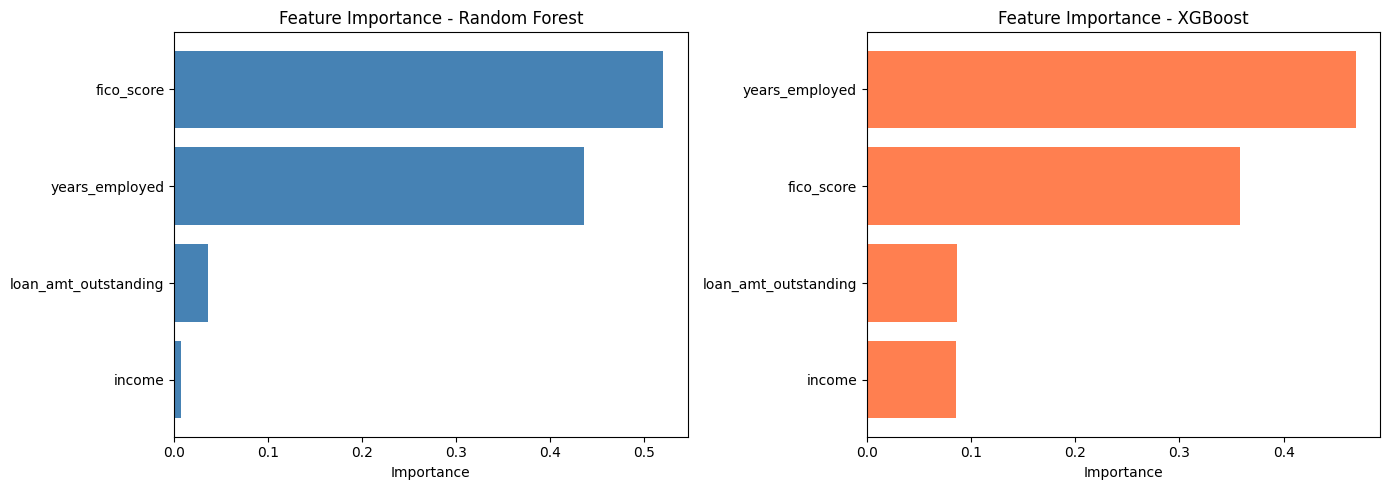


Logistic Regression - Coefficients absolus (features scalees) :
income                  0.000000
loan_amt_outstanding    0.115921
years_employed          0.586567
fico_score              0.715987
dtype: float64

>> Random Forest: importance repartie (max = 52.0%), pas de leakage evident

>> XGBoost: importance repartie (max = 46.9%), pas de leakage evident


In [377]:
# ====================================
#  Feature Importance
# ====================================
feature_names = X.columns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest feature importance
if "Random Forest" in best_models:
    rf_model = best_models["Random Forest"].named_steps['model']
    importances_rf = rf_model.feature_importances_
    idx_rf = np.argsort(importances_rf)
    axes[0].barh(feature_names[idx_rf], importances_rf[idx_rf], color='steelblue')
    axes[0].set_title("Feature Importance - Random Forest")
    axes[0].set_xlabel("Importance")

# XGBoost feature importance
if "XGBoost" in best_models:
    xgb_model = best_models["XGBoost"].named_steps['model']
    importances_xgb = xgb_model.feature_importances_
    idx_xgb = np.argsort(importances_xgb)
    axes[1].barh(feature_names[idx_xgb], importances_xgb[idx_xgb], color='coral')
    axes[1].set_title("Feature Importance - XGBoost")
    axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

# Logistic Regression coefficients
if "Logistic Regression" in best_models:
    lr_model = best_models["Logistic Regression"].named_steps['model']
    coefs = pd.Series(lr_model.coef_[0], index=feature_names).abs().sort_values()
    print("\nLogistic Regression - Coefficients absolus (features scalées) :")
    print(coefs)

# Verification : une feature concentre-t-elle > 80% de l'importance ?
for name_model in ["Random Forest", "XGBoost"]:
    if name_model in best_models:
        imp = best_models[name_model].named_steps['model'].feature_importances_
        max_imp = imp.max()
        if max_imp > 0.80:
            print(f"\n>> ALERTE {name_model}: une feature concentre {max_imp:.1%} de l'importance (leakage probable)")
        else:
            print(f"\n>> {name_model}: importance répartie (max = {max_imp:.1%}), pas de leakage évident")

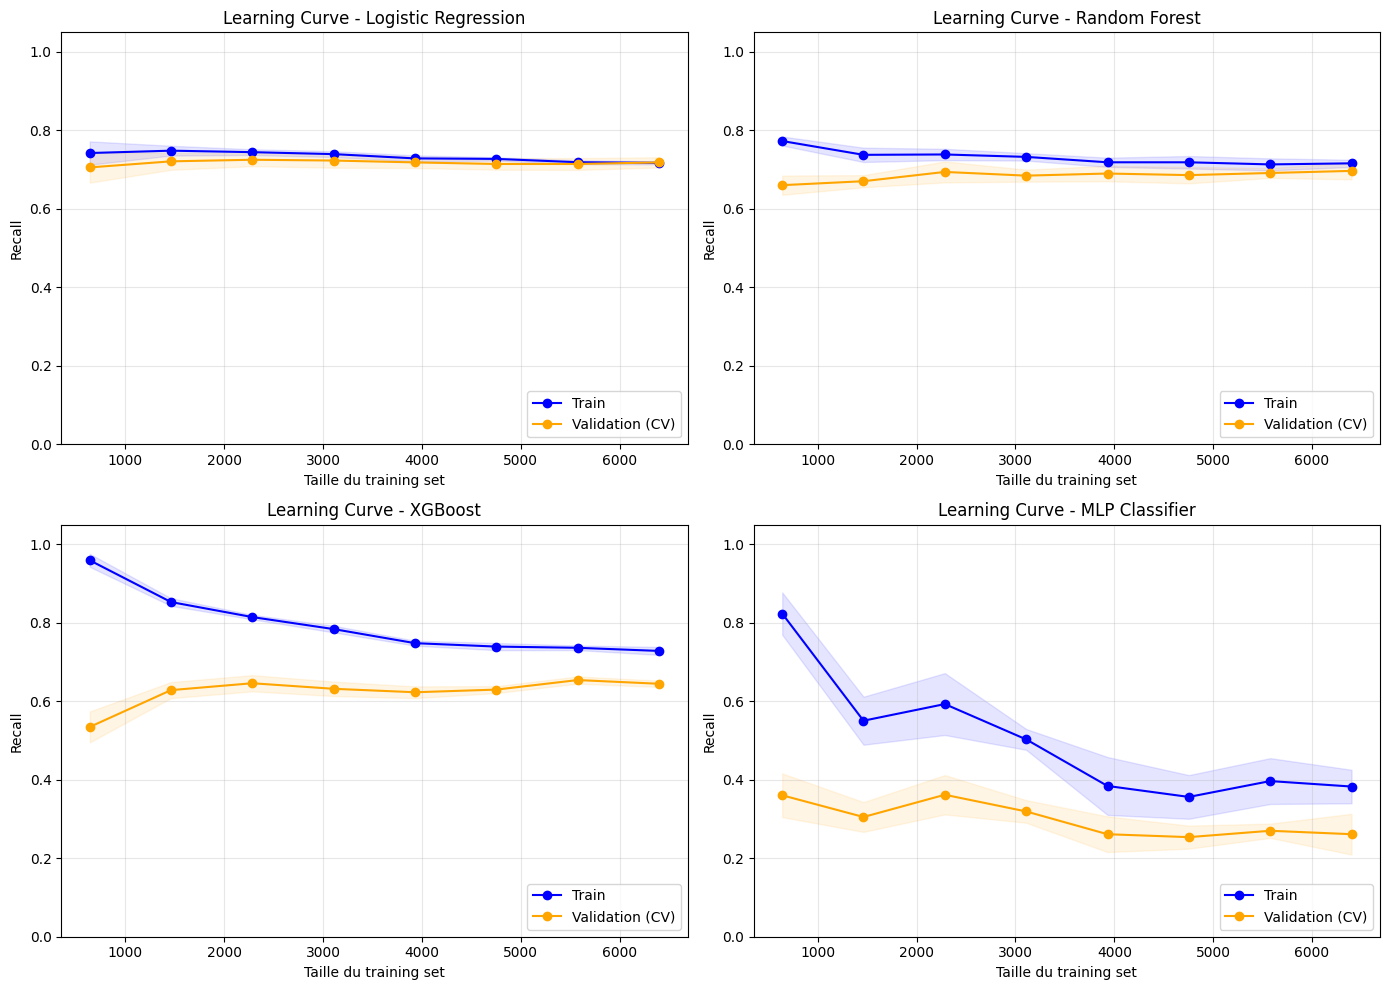

Si train >> validation avec un ecart constant = overfitting
Si les deux courbes convergent vers un score eleve = bon modele
Si les deux courbes sont basses = underfitting


In [378]:
# ====================================
#  Learning Curves
# ====================================
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (name, model_pipeline) in enumerate(best_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model_pipeline, X_train, y_train,
        cv=stratifiedkfold,
        scoring='recall',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    ax = axes[idx]
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='orange')
    ax.plot(train_sizes, train_mean, 'o-', color='blue', label='Train')
    ax.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation (CV)')
    ax.set_title(f'Learning Curve - {name}')
    ax.set_xlabel('Taille du training set')
    ax.set_ylabel('Recall')
    ax.legend(loc='lower right')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Si train >> validation avec un écart constant = overfitting")
print("Si les deux courbes convergent vers un score élevé = bon modèle")
print("Si les deux courbes sont basses = underfitting")

# Test de robustesse avec SMOTE
**SMOTE** (Synthetic Minority Over-sampling Technique) génère des échantillons synthétiques de la classe minoritaire (`default=1`) par interpolation entre les k plus proches voisins réels.
SMOTE crée des échantillons **dans le même espace** que les données d'entraînement, ce qui permet :
1. D'équilibrer les classes pour l'entrainement
2. De tester le modele sur des défauts synthétiques réalistes
3. De vérifier que le modèle distingue bien les vrais non-defauts des faux defauts generes

**Important** : SMOTE s'applique UNIQUEMENT sur le train set (jamais sur le test) pour éviter tout leakage.


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -

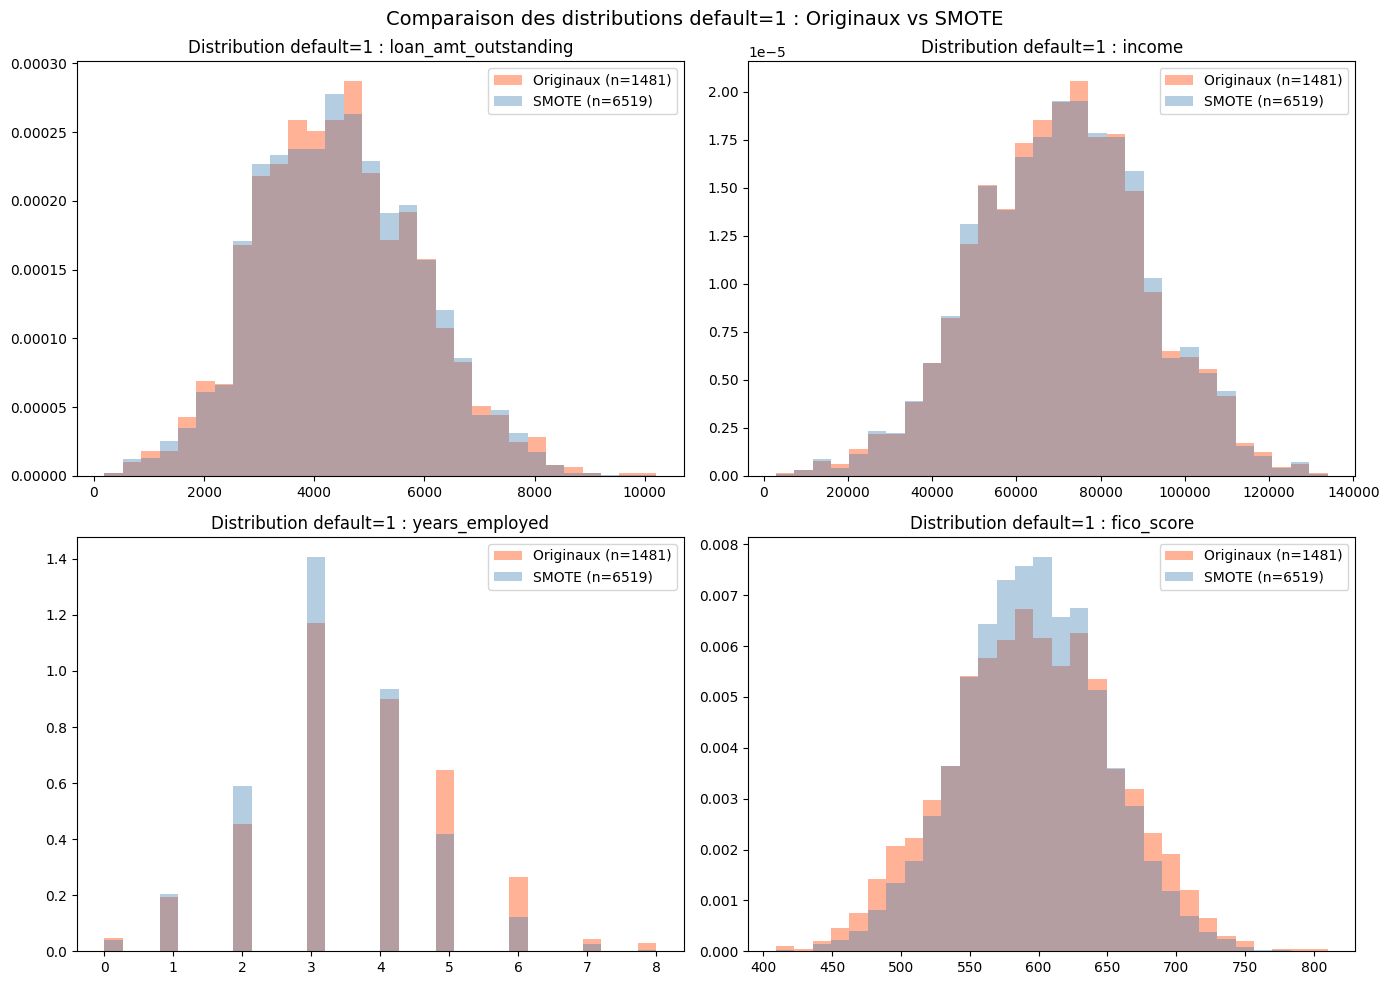

In [383]:
# ====================================
#  SMOTE : Génération de défauts synthétiques
# ====================================


!pip install -U scikit-learn imbalanced-learn
from imblearn.over_sampling import SMOTE


smote = SMOTE(random_state=seeds, k_neighbors=5)

# On applique SMOTE sur le train set UNIQUEMENT
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== Avant SMOTE (train) ===")
print(f"  Total : {len(y_train)}")
print(f"  Default=0 : {(y_train == 0).sum()} ({(y_train == 0).mean():.1%})")
print(f"  Default=1 : {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})")

print(f"\n=== Apres SMOTE (train) ===")
print(f"  Total : {len(y_train_smote)}")
print(f"  Default=0 : {(y_train_smote == 0).sum()} ({(y_train_smote == 0).mean():.1%})")
print(f"  Default=1 : {(y_train_smote == 1).sum()} ({(y_train_smote == 1).mean():.1%})")

n_synthetiques = len(y_train_smote) - len(y_train)
print(f"\n  => {n_synthetiques} échantillons default=1 générés par SMOTE")

# Visualisation : comparaison distributions avant/apres SMOTE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
feature_cols = X_train.columns

for idx, col in enumerate(feature_cols[:4]):
    ax = axes[idx // 2][idx % 2]
    
    # Originaux default=1
    orig_default = X_train[y_train == 1][col]
    # SMOTE default=1 (inclut originaux + synthetiques)
    smote_default = pd.Series(
        X_train_smote[y_train_smote == 1][col].values if hasattr(X_train_smote, 'columns')
        else X_train_smote[y_train_smote == 1, idx],
        name=col
    )
    
    ax.hist(orig_default, bins=30, alpha=0.6, label=f'Originaux (n={len(orig_default)})', color='coral', density=True)
    ax.hist(smote_default, bins=30, alpha=0.4, label=f'SMOTE (n={len(smote_default)})', color='steelblue', density=True)
    ax.set_title(f'Distribution default=1 : {col}')
    ax.legend()

plt.suptitle('Comparaison des distributions default=1 : Originaux vs SMOTE', fontsize=14)
plt.tight_layout()
plt.show()

  COMPARAISON : Modeles originaux vs Modeles entraines avec SMOTE


c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Bernard\OneDrive - Bernab\DU DataAnalytics PS1\MLOPS\ProjetMLOPS\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



  Logistic Regression
Metrique               Sans SMOTE   Avec SMOTE      Delta
-------------------------------------------------------
Accuracy                   0.7100       0.7310   +0.0210 ↑
Recall                     0.7027       0.6730   -0.0297 ↓
Precision                  0.3562       0.3739   +0.0177 ↑
F1-score                   0.4727       0.4807   +0.0080 ↑
AUC-ROC                    0.7796       0.7795   -0.0001 ≈

  Random Forest
Metrique               Sans SMOTE   Avec SMOTE      Delta
-------------------------------------------------------
Accuracy                   0.7080       0.7330   +0.0250 ↑
Recall                     0.6568       0.6595   +0.0027 ≈
Precision                  0.3471       0.3742   +0.0271 ↑
F1-score                   0.4542       0.4775   +0.0233 ↑
AUC-ROC                    0.7719       0.7731   +0.0012 ≈

  XGBoost
Metrique               Sans SMOTE   Avec SMOTE      Delta
-------------------------------------------------------
Accuracy         

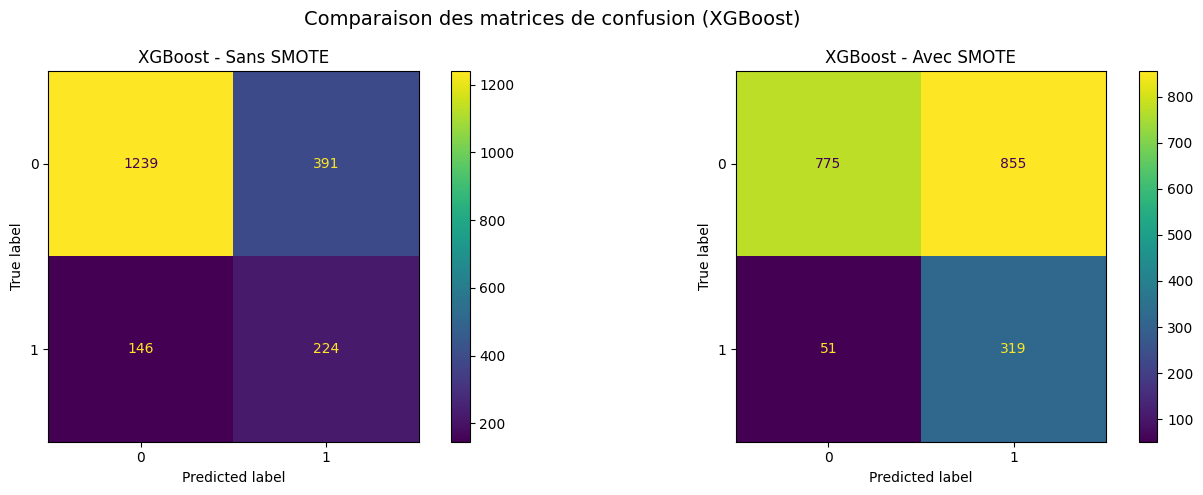


Meilleur modele (recall sur test) : XGBoost
SMOTE ameliore generalement le recall (detection des defauts)
au prix d'une legere baisse de precision (plus de faux positifs).


In [384]:
# ====================================
#  Ré-entraînement avec SMOTE et comparaison
# ====================================
# On ré-entraîne les modèles sur les données équilibrées par SMOTE
# et on compare les performances sur le MEME test set (non modifie)

best_models_smote = {}
print("=" * 70)
print("  COMPARAISON : Modèles originaux vs Modèles entraînés avec SMOTE")
print("=" * 70)

for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", sklearn.base.clone(model))
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=gridsearch_params[name],
        cv=stratifiedkfold,
        scoring="recall",
        n_jobs=-1,
        refit=True
    )

    # Entrainement sur donnees SMOTE
    grid.fit(X_train_smote, y_train_smote)

    best_smote = grid.best_estimator_
    best_models_smote[name] = best_smote

    # Predictions sur le test set (JAMAIS touche par SMOTE)
    y_pred_orig = best_models[name].predict(X_test)
    y_pred_smote = best_smote.predict(X_test)

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"{'Metrique':<20} {'Sans SMOTE':>12} {'Avec SMOTE':>12} {'Delta':>10}")
    print(f"{'-'*55}")

    for metric_name, metric_fn in [
        ("Accuracy", accuracy_score),
        ("Recall", recall_score),
        ("Precision", precision_score),
        ("F1-score", f1_score),
    ]:
        score_orig = metric_fn(y_test, y_pred_orig)
        score_smote = metric_fn(y_test, y_pred_smote)
        delta = score_smote - score_orig
        arrow = "↑" if delta > 0.005 else ("↓" if delta < -0.005 else "≈")
        print(f"{metric_name:<20} {score_orig:>12.4f} {score_smote:>12.4f} {delta:>+9.4f} {arrow}")

    # AUC-ROC si le modele supporte predict_proba
    try:
        proba_orig = best_models[name].predict_proba(X_test)[:, 1]
        proba_smote = best_smote.predict_proba(X_test)[:, 1]
        auc_orig = roc_auc_score(y_test, proba_orig)
        auc_smote = roc_auc_score(y_test, proba_smote)
        delta_auc = auc_smote - auc_orig
        arrow = "↑" if delta_auc > 0.005 else ("↓" if delta_auc < -0.005 else "≈")
        print(f"{'AUC-ROC':<20} {auc_orig:>12.4f} {auc_smote:>12.4f} {delta_auc:>+9.4f} {arrow}")
    except AttributeError:
        pass

# Matrices de confusion comparees (meilleur modele)
best_name = max(best_models_smote.keys(),
                key=lambda k: recall_score(y_test, best_models_smote[k].predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, best_models[best_name].predict(X_test), ax=axes[0])
axes[0].set_title(f'{best_name} - Sans SMOTE')

ConfusionMatrixDisplay.from_predictions(y_test, best_models_smote[best_name].predict(X_test), ax=axes[1])
axes[1].set_title(f'{best_name} - Avec SMOTE')

plt.suptitle(f'Comparaison des matrices de confusion ({best_name})', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nMeilleur modèle (recall sur test) : {best_name}")
print("SMOTE améliore généralement le recall (détection des défauts)")
print("au prix d'une légère baisse de précision (plus de faux positifs).")

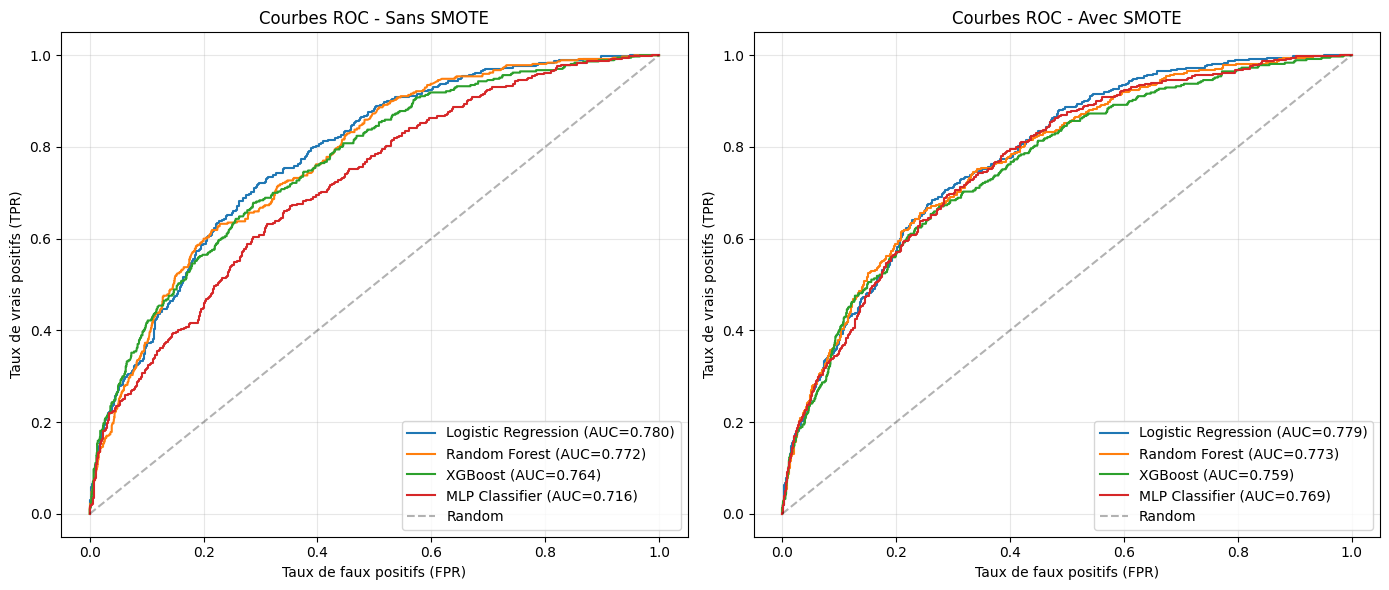

L'AUC-ROC mesure la capacite globale de discrimination du modele.
Si AUC augmente avec SMOTE, le modele beneficie de l'equilibrage des classes.


In [385]:
# ====================================
#  Courbes ROC comparatives : Sans SMOTE vs Avec SMOTE
# ====================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, models_dict) in zip(axes, [("Sans SMOTE", best_models), ("Avec SMOTE", best_models_smote)]):
    for name, mdl in models_dict.items():
        try:
            y_proba = mdl.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc = roc_auc_score(y_test, y_proba)
            ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
        except AttributeError:
            pass
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
    ax.set_title(f'Courbes ROC - {label}')
    ax.set_xlabel('Taux de faux positifs (FPR)')
    ax.set_ylabel('Taux de vrais positifs (TPR)')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("L'AUC-ROC mesure la capacité globale de discrimination du modèle.")
print("Si AUC augmente avec SMOTE, le modèle bénéficie de l'équilibrage des classes.")